In [1]:
import os
import warnings


# '3' doar erorile critice 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')

print("warning-uri ascunse")

warning-uri ascunse


In [10]:
import numpy as np
import os
import zipfile
import io
import shutil
from scipy.ndimage import zoom
from tqdm import tqdm


VAL_IMG_PATH = '/kaggle/input/datasets/ramonacrciun/openbhb/val_quasiraw'
TRAIN_IMG_PATH = '/kaggle/input/datasets/ramonacrciun/openbhb/train_quasiraw'
VAL_ZIP = '/kaggle/working/val_preprocessed.zip'
TRAIN_ZIP = '/kaggle/working/train_preprocessed.zip'

TARGET_DIM = (107, 128, 107)

def preprocess_to_zip(src_dir, zip_path):
    if not os.path.exists(src_dir):
        print(f"Eroare: Sursa {src_dir} nu exista!")
        return
        
    files = [f for f in os.listdir(src_dir) if f.endswith('.npy')]
    print(f"Gasite {len(files)} fiaiere in {os.path.basename(src_dir)}")

    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_STORED) as z:
        for fname in tqdm(files, desc=f"Procesare {os.path.basename(src_dir)}"):
            try:
                # Incarcare
                img = np.load(os.path.join(src_dir, fname))
                img = np.squeeze(img)

                # Resize / Zoom
                if img.shape != TARGET_DIM:
                    zoom_factors = [t / o for t, o in zip(TARGET_DIM, img.shape)]
                    img = zoom(img, zoom_factors, order=1)

                # Clip outlieri
                p1, p99 = np.percentile(img, [1, 99])
                img = np.clip(img, p1, p99)

                # Normalizare
                img = (img - img.mean()) / (img.std() + 1e-8)
                img = img.astype(np.float32)

                # Salvare in RAM ai scriere in ZIP
                buffer = io.BytesIO()
                np.save(buffer, img)
                z.writestr(fname, buffer.getvalue())
            except Exception as e:
                print(f"Eroare la fiaierul {fname}: {e}")


preprocess_to_zip(VAL_IMG_PATH, VAL_ZIP)

print(f"\nProces finalizat cu succes!")
print(f"Fiaiere rezultate: {os.listdir('/kaggle/working')}")

Memoria /kaggle/working a fost curățată complet!
Găsite 757 fișiere în val_quasiraw


Procesare val_quasiraw: 100%|██████████| 757/757 [08:48<00:00,  1.43it/s]


Proces finalizat cu succes!
Fișiere rezultate: ['val_preprocessed.zip']


In [3]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv3D, Dense, Dropout, Input, BatchNormalization,GlobalAveragePooling3D, MaxPooling3D, Add,Activation, Reshape, Multiply, SpatialDropout3D)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
import tensorflow.keras.backend as K
import pickle
from IPython.display import FileLink, display, HTML

strategy = tf.distribute.MirroredStrategy()
print(f'placi video folosite: {strategy.num_replicas_in_sync}')

TRAIN_LABELS_PATH  = '/kaggle/input/datasets/ramonacrciun/openbhb/train_labels/participants.tsv'
VAL_LABELS_PATH    = '/kaggle/input/datasets/ramonacrciun/openbhb/val_labels/participants.tsv'

TRAIN_PREPROCESSED = '/kaggle/input/datasets/craciunramona/preprocesari/train_preprocessed'
VAL_PREPROCESSED   = '/kaggle/input/datasets/craciunramona/preprocesari/val_preprocessed'

MODEL_SAVE_PATH    = '/kaggle/working/model_final.keras'
HISTORY_PATH       = '/kaggle/working/history_final.pkl'

os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

TARGET_DIM        = (107, 128, 107)
BATCH_SIZE        = 16
EPOCHS            = 60
INPUT_SHAPE_FINAL = (*TARGET_DIM, 1)

# Squeeze-and-Excitation Block
def se_block(x, ratio=8):  #ratio factor de compresie
    
    filters = x.shape[-1]  #nr canale
    se = GlobalAveragePooling3D()(x)
    se = Dense(filters // ratio, activation='relu',kernel_initializer='he_uniform')(se)
    se = Dense(filters, activation='sigmoid',kernel_initializer='glorot_uniform')(se)  #vector scor de atentie intre 0 si 1
    se = Reshape((1, 1, 1, filters))(se)  #reshape pt inmultire
    
    return Multiply()([x, se])  #img inmultit cu scorul de atentie al fiecarui canal

def resnet_se_block(x, filters, strides=1):
    
    shortcut = x

    x = Conv3D(filters, (3,3,3), strides=strides, padding='same', kernel_initializer='he_uniform', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = BatchNormalization(momentum=0.99)(x)
    x = Activation('relu')(x)

    x = Conv3D(filters, (3,3,3), strides=1, padding='same',kernel_initializer='he_uniform',kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = BatchNormalization(momentum=0.99)(x)

    x = se_block(x, ratio=8)

    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv3D(filters, (1,1,1), strides=strides, padding='same',kernel_initializer='he_uniform')(shortcut)
        shortcut = BatchNormalization(momentum=0.99)(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def create_resnet_se_model(input_shape):
    
    inputs = Input(shape=input_shape)

    x = Conv3D(32, (3,3,3), padding='same', kernel_initializer='he_uniform')(inputs)
    x = BatchNormalization(momentum=0.99)(x)
    x = Activation('relu')(x)
    x = MaxPooling3D((2,2,2))(x)                     

    x = resnet_se_block(x, filters=64,  strides=2)   
    x = SpatialDropout3D(0.1)(x)

    x = resnet_se_block(x, filters=128, strides=2)  
    x = SpatialDropout3D(0.1)(x)

    x = resnet_se_block(x, filters=256, strides=2)  

    x = GlobalAveragePooling3D()(x)

    x = Dense(256, activation='relu', kernel_initializer='he_uniform',kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu',kernel_initializer='he_uniform',kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='linear', kernel_initializer='he_uniform')(x)

    return Model(inputs, outputs)

def load_dataset(img_path, labels_path):
    
    files = [f for f in os.listdir(img_path) if f.endswith('.npy')]
    df_paths = pd.DataFrame({
        'participant_id': [f.split('_')[0].replace('sub-', '') for f in files],
        'full_path': [os.path.join(img_path, f) for f in files]
    })
    
    df_labels = pd.read_csv(labels_path, sep='\t')
    df_labels['participant_id'] = df_labels['participant_id'].astype(str)
    df_paths['participant_id']  = df_paths['participant_id'].astype(str)
    df_merged = pd.merge(df_paths, df_labels[['participant_id', 'age']],
                         on='participant_id', how='inner')
    
    return df_merged.reset_index(drop=True)

df_train = load_dataset(TRAIN_PREPROCESSED, TRAIN_LABELS_PATH)
df_val   = load_dataset(VAL_PREPROCESSED,   VAL_LABELS_PATH)

train_IDs = df_train.index.values
val_IDs   = df_val.index.values

print("-" * 50)
print(f"Train = {len(df_train)} | Val = {len(df_val)}")
print("-" * 50)

# radical sklearn balanced (su)
bins       = [0, 12, 18, 30, 40, 50, 60, 70, 90]
bin_labels = ['0-12', '12-18', '18-30', '30-40', '40-50', '50-60', '60-70', '70-90']

df_train['age_bin'] = pd.cut(df_train['age'], bins=bins, labels=False)
class_counts        = df_train['age_bin'].value_counts().to_dict()
n_classes           = len(class_counts)
n_samples           = len(df_train)

unique_weights = {
    idx: np.sqrt(n_samples / (n_classes * count)) 
    for idx, count in class_counts.items()
}

suma_ponderi_bins = sum(unique_weights.values())

df_train['weight'] = df_train['age_bin'].apply(
    lambda x: unique_weights[x] / suma_ponderi_bins  #normalizarea ponderilor la suma lor
)

print(f"{'Grupa':>10} | {'Nr. pacienti':>12} | {'Weight':>10}")
print("-" * 45)

for idx in sorted(class_counts):
    label = bin_labels[int(idx)]
    n = class_counts[idx]
    w_final = unique_weights[idx] / suma_ponderi_bins
    print(f"{label:>10} | {n:>12} | {w_final:>10.4f}")

print("-" * 45)
print(f"Suma ponderilor pe cele {n_classes} categorii inainte de normalizare: {suma_ponderi_bins:.4f}")
print(f"Verificare: {df_train.drop_duplicates('age_bin')['weight'].sum():.4f}")
print(f"Suma totala a tuturor ponderilor din dataset: {df_train['weight'].sum():.4f}")

train_labels = df_train[['age', 'full_path', 'weight']]
val_labels   = df_val[['age', 'full_path']]

class DataGenerator(Sequence):
    def __init__(self, list_IDs, labels, batch_size=16, dim=(107, 128, 107),
                 n_channels=1, shuffle=True, is_training=True, **kwargs):
        super().__init__(**kwargs)
        self.dim         = dim
        self.batch_size  = batch_size
        self.labels      = labels
        self.list_IDs    = list_IDs
        self.n_channels  = n_channels
        self.shuffle     = shuffle
        self.is_training = is_training
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        list_IDs_temp = [self.list_IDs[k] for k in indexes]
        return self.__data_generation(list_IDs_temp)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_IDs_temp):
        X = np.empty((self.batch_size, *self.dim, self.n_channels), dtype=np.float32)
        y = np.empty((self.batch_size, 1),dtype=np.float32)
        w = np.empty((self.batch_size,), dtype=np.float32)

        for i, ID in enumerate(list_IDs_temp):
            img  = np.load(self.labels.loc[ID, 'full_path'])
            X[i] = np.expand_dims(img, axis=-1)
            y[i] = self.labels.loc[ID, 'age']
            if self.is_training:
                w[i] = self.labels.loc[ID, 'weight']

        if self.is_training:
            return X, y, w  
        else:
            return X, y


class StableValMAE(Callback):
    def __init__(self, val_generator):
        super().__init__()
        self.val_generator = val_generator
        self.best_mae      = np.inf
        self.history_mae   = []

    def on_epoch_end(self, epoch, logs=None):  
        y_true, y_pred = [], []
        for i in range(len(self.val_generator)):  #parcurg tot setul de validare si fac predictii
            X_batch, y_batch = self.val_generator[i]
            pred = self.model.predict(X_batch, verbose=0)
            y_true.extend(y_batch.flatten())
            y_pred.extend(pred.flatten())

        mae = float(np.mean(np.abs(np.array(y_true) - np.array(y_pred))))  #calculeaz mae pe tot setul de validare
        self.history_mae.append(mae)

        if logs is not None:
            logs['val_mae'] = mae  #dau ca metrica valoarea calculata pe tot setul de validare

        marker = ''
        if mae < self.best_mae:
            self.best_mae = mae
            marker = ' ← best'
        print(f"  val_mae_stable: {mae:.4f}{marker}")
        

def mae_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def cosine_annealing(epoch):
    initial_lr = 0.0001
    min_lr     = 1e-6
    cosine_val = np.cos(np.pi * epoch / EPOCHS)
    return float(min_lr + 0.5 * (initial_lr - min_lr) * (1 + cosine_val))

with strategy.scope():
    model_resnet_se = create_resnet_se_model(INPUT_SHAPE_FINAL)
    model_resnet_se.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),loss=mae_loss,metrics=['mae'])

#model_resnet_se.summary()

training_generator   = DataGenerator(train_IDs, train_labels,batch_size=BATCH_SIZE,shuffle=True, is_training=True)
validation_generator = DataGenerator(val_IDs, val_labels,batch_size=BATCH_SIZE,shuffle=False, is_training=False)

class LrChangeLogger(Callback):
    def on_train_begin(self, logs=None):
        self.last_lr = float(K.get_value(self.model.optimizer.learning_rate))
        print(f"Learning rate initial: {self.last_lr:.8f}")

    def on_epoch_end(self, epoch, logs=None):
        lr = float(K.get_value(self.model.optimizer.learning_rate))
        if abs(lr - self.last_lr) > 1e-8:
            print(f"Epoch {epoch+1}: LR → {lr:.8f}")
            self.last_lr = lr
            
stable_val_mae = StableValMAE(validation_generator)
checkpoint     = ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_mae',save_best_only=True, mode='min', verbose=1)
early_stopping = EarlyStopping(monitor='val_mae', patience=20,restore_best_weights=True)
lr_schedule    = LearningRateScheduler(cosine_annealing, verbose=0)
lr_logger      = LrChangeLogger()

callbacks_list = [stable_val_mae, checkpoint, early_stopping, lr_schedule, lr_logger]


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
placi video folosite: 2
--------------------------------------------------
Train = 2900 | Val = 757
--------------------------------------------------
     Grupa | Nr. pacienti |     Weight
---------------------------------------------
      0-12 |          342 |     0.0834
     12-18 |          293 |     0.0901
     18-30 |         1773 |     0.0366
     30-40 |          132 |     0.1342
     40-50 |           83 |     0.1693
     50-60 |           93 |     0.1599
     60-70 |          110 |     0.1471
     70-90 |           74 |     0.1793
---------------------------------------------
Suma ponderilor pe cele 8 categorii inainte de normalizare: 12.3439
Verificare: 1.0000
Suma totala a tuturor ponderilor din dataset: 195.9650


In [12]:

print(f"--- LANSAREA ANTRENaRII: {len(df_train)} subiecti ---")
history = model_resnet_se.fit(
    training_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)
print("Antrenarea s-a incheiat.")


with open(HISTORY_PATH, 'wb') as f:
    pickle.dump({
        'mae':     history.history['mae'],
        'val_mae': stable_val_mae.history_mae,  # val_mae stabil
        'loss':    history.history['loss'],
        'val_loss':history.history['val_loss']
    }, f)

print(f"Istoricul salvat la: {HISTORY_PATH}")
print(f"Cel mai bun val_mae stabil: {stable_val_mae.best_mae:.4f} ani")
print(f"LR final: {float(K.get_value(model_resnet_se.optimizer.learning_rate)):.8f}")


--- LANSAREA ANTRENĂRII: 2900 subiecți ---
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Learning rate initial: 0.00010000
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadca

I0000 00:00:1776973072.759619     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - loss: 1.4863 - mae: 17.2449INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
  val_mae_stable: 9.1676 ← best

Epoch 1: val_mae improved from inf to 9.16761, saving model to /kaggle/working/model_final.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - loss: 1.4846 - mae: 17.2209 - val_loss: 18.5734 - val_mae: 9.1676 - learning_rate: 1.0000e-04
Epoch 2/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - loss: 0.9395 - mae: 9.5119  val_mae_stable: 7.5390 ← best

Epoch 2: val_mae improved from 9.16761 to 7.53903, saving model to /kaggle/working/model_final.keras
Epoch 2: LR → 0.00009993
181/181 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - loss: 0.9394 - mae: 9.5113 - val_loss: 15.3009 - val_mae: 7.5390 - learning_rate: 9.9932e-05
Epoch 3/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - loss: 0.8847 - mae: 8.9042  val_mae_stable: 8.2712

Epoch 3: val_mae did not improve f

Dimensiune fișier: (107, 128, 107)


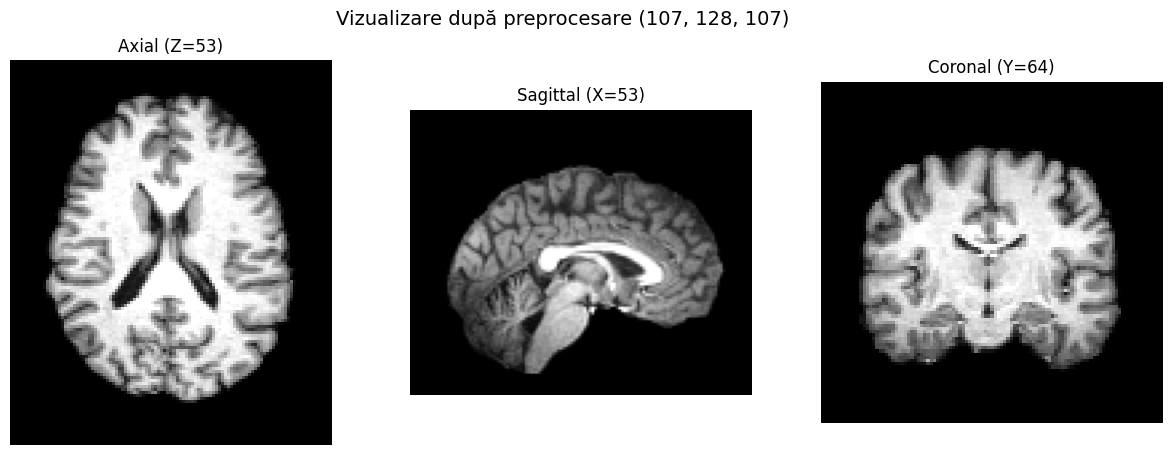

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os

FILE_PATH = '/kaggle/input/datasets/craciunramona/preprocesari/val_preprocessed/sub-314405766761_preproc-quasiraw_T1w.npy'
TARGET_DIM = (107, 128, 107)

def vizualizeaza_dupa_modelul_tau(path, target_dim):
    if not os.path.exists(path):
        print(f"Fiaierul nu a fost gasit la: {path}")
        return

    img = np.load(path)
    img = np.squeeze(img) 

    mid = np.array(target_dim) // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Axial
    axes[0].imshow(np.rot90(img[:, :, mid[2]], k=1), cmap='gray')
    axes[0].set_title(f"Axial (Z={mid[2]})")
    axes[0].axis('off')

    # Sagital
    axes[1].imshow(np.rot90(img[mid[0], :, :], k=1), cmap='gray')
    axes[1].set_title(f"Sagittal (X={mid[0]})")
    axes[1].axis('off')

    # Coronal 
    axes[2].imshow(np.rot90(img[:, mid[1], :], k=1), cmap='gray')
    axes[2].set_title(f"Coronal (Y={mid[1]})")
    axes[2].axis('off')

    print(f"Dimensiune fiaier: {img.shape}")
    plt.suptitle(f"Vizualizare dupa preprocesare {target_dim}", fontsize=14)
    plt.show()

vizualizeaza_dupa_modelul_tau(FILE_PATH, TARGET_DIM)

In [4]:
#afisare train si val 
import pandas as pd

pd.set_option('display.max_rows', None)

df_train_all = df_train.sort_values(by='age', ascending=False)
df_val_all = df_val.sort_values(by='age', ascending=False)

print(f"--- SET ANTRENARE COMPLET ({len(df_train_all)} subiecti) ---")
print(df_train_all[['participant_id', 'age']].to_string(index=False))

print("\n" + "="*50 + "\n")

print(f"--- SET VALIDARE COMPLET ({len(df_val_all)} subiecti) ---")
print(df_val_all[['participant_id', 'age']].to_string(index=False))

pd.reset_option('display.max_rows')

--- SET ANTRENARE COMPLET (2900 subiecți) ---
participant_id       age
  713258499606 86.198494
  717521415493 83.811088
  672056914948 83.457906
  519085723694 83.000000
  725785336385 82.187543
  345814656280 81.941136
  843302791192 80.169747
  592747222720 79.414100
  762833422997 79.000000
  241739908307 79.000000
  564557955687 79.000000
  230496424118 78.584531
  207275791415 78.203970
  387138524123 78.072553
  701863915807 77.500000
  854248757945 77.500000
  522535703135 77.000000
  887424714190 76.000000
  368153573682 75.972621
  477160054985 75.937029
  562931531957 75.827515
  954946498969 75.633128
  544128411470 74.989733
  327818254945 74.636550
  848303531880 74.026010
  890363771287 74.012320
  287389356878 74.000000
  707270874156 74.000000
  674592363321 73.563313
  429746311818 73.544148
  913628264858 73.538672
  467659061528 73.182752
  919267100021 73.015743
  331344566757 73.000000
  421100177732 72.884326
  614478580712 72.826831
  790241781136 72.594114
  27

In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf

MODEL_SAVE_PATH = '/kaggle/working/model_final.keras' # 3.86074 mae

def mae_mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

model_3d_cnn = tf.keras.models.load_model(
    MODEL_SAVE_PATH,
    custom_objects={'mae_mse_loss': mae_mse_loss}
)

y_pred_list = []
y_true_list = []

for i in range(len(validation_generator)):
    X_batch, y_batch = validation_generator[i]
    pred = model_3d_cnn.predict(X_batch, verbose=0)
    y_pred_list.extend(pred.flatten().tolist())
    y_true_list.extend(y_batch.flatten().tolist())

y_pred_final = np.array(y_pred_list)
y_true_final = np.array(y_true_list)

errors_abs = np.abs(y_pred_final - y_true_final)
bad_raw    = y_pred_final - y_true_final

df_outlieri = pd.DataFrame({
    'ID_Participant':       df_val['participant_id'].values[:len(y_pred_final)],
    'Varsta_Reala':         np.round(y_true_final, 2),
    'Varsta_Prezisa':       np.round(y_pred_final, 2),
    'Eroare_Absoluta':      np.round(errors_abs, 2),
    'Brain_Age_Delta (BAD)':np.round(bad_raw, 2)
})

mae_final = df_outlieri['Eroare_Absoluta'].mean()

print(f"\n MAE model: {mae_final:.4f}")

top_outlieri = df_outlieri.sort_values(by='Eroare_Absoluta', ascending=False).head(757)

print(f"\nTotal pacienti prezisi: {len(y_pred_final)}")
print("\nANALIZA")
print("-" * 80)
print(top_outlieri.to_string(index=False))
print("-" * 80)


 MAE model: 3.8622

Total pacienți prezisi: 752

ANALIZĂ
--------------------------------------------------------------------------------
ID_Participant  Vârsta_Reală  Vârsta_Prezisă  Eroare_Absolută  Brain_Age_Delta (BAD)
  561910282184         65.91           38.92            26.99                 -26.99
  818488071158         62.02           36.78            25.24                 -25.24
  471337118066         62.00           37.56            24.44                 -24.44
  314405766761         11.91           35.29            23.38                  23.38
  352362867687         57.50           34.47            23.03                 -23.03
  710478531957         31.59           54.23            22.64                  22.64
  427425670013         88.00           65.49            22.51                 -22.51
  177266966580         66.33           44.82            21.51                 -21.51
  768484359908         72.01           50.73            21.28                 -21.28
  700112268

In [14]:
import pandas as pd
import io

raw_data = """ID_Participant  Varsta_Reala  Varsta_Prezisa  Eroare_Absoluta  Brain_Age_Delta (BAD)
  561910282184         65.91           38.92            26.99                 -26.99
  818488071158         62.02           36.78            25.24                 -25.24
  471337118066         62.00           37.56            24.44                 -24.44
  314405766761         11.91           35.29            23.38                  23.38
  352362867687         57.50           34.47            23.03                 -23.03
  710478531957         31.59           54.23            22.64                  22.64
  427425670013         88.00           65.49            22.51                 -22.51
  177266966580         66.33           44.82            21.51                 -21.51
  768484359908         72.01           50.73            21.28                 -21.28
  700112268139         39.18           60.43            21.25                  21.25
  547107069770         67.50           46.63            20.87                 -20.87
  414543641992         39.04           59.17            20.13                  20.13
  996920646374         34.21           53.97            19.76                  19.76
  657669884728         46.43           26.69            19.74                 -19.74
  305566005237         62.51           43.55            18.96                 -18.96
  912370247196         58.99           40.10            18.90                 -18.90
  198639009666         48.00           29.23            18.77                 -18.77
  684779203605         40.00           21.24            18.76                 -18.76
  427477880682         17.90           36.14            18.24                  18.24
  242741538964         42.50           24.33            18.17                 -18.17
  517104081867         86.32           68.18            18.14                 -18.14
  271658975814         46.30           28.78            17.52                 -17.52
  445630050591         45.30           27.94            17.36                 -17.36
  884084203320         70.52           53.18            17.34                 -17.34
  877746416294         45.03           27.96            17.08                 -17.08
  378495374350         75.08           58.12            16.96                 -16.96
  883686860970         40.00           23.31            16.69                 -16.69
  277976850330         78.36           62.09            16.27                 -16.27
  411371553282         40.00           23.87            16.13                 -16.13
  609282895955         38.59           54.68            16.09                  16.09
  639095184054         63.00           47.19            15.81                 -15.81
  826636241714         24.00           39.80            15.80                  15.80
  237746771571         30.00           45.50            15.50                  15.50
  369378114293         53.00           37.86            15.14                 -15.14
  513335424069         70.14           55.24            14.90                 -14.90
  722160277938         60.00           45.10            14.90                 -14.90
  419968465879         73.00           87.86            14.86                  14.86
  395384646781         40.00           25.75            14.25                 -14.25
  136660172869         47.35           61.46            14.11                  14.11
  721147018160         41.00           27.03            13.97                 -13.97
  468836030322         15.80           28.42            12.62                  12.62
  135174484625         21.00           33.41            12.41                  12.41
  487672006646         59.26           47.00            12.27                 -12.27
  919572007730         30.12           42.34            12.22                  12.22
  886465425609         47.00           34.82            12.18                 -12.18
  601230696909         36.00           23.83            12.17                 -12.17
  610887047293         69.07           81.18            12.11                  12.11
  317793059909         34.01           22.04            11.96                 -11.96
  730968832318         61.37           49.56            11.81                 -11.81
  770282132150         59.74           47.95            11.79                 -11.79
  984535611500         41.74           53.50            11.76                  11.76
  534784570154         72.00           83.68            11.68                  11.68
  928641172711         10.20           21.84            11.64                  11.64
  107989352584         38.00           26.44            11.56                 -11.56
  824381268107         35.00           23.55            11.45                 -11.45
  619612744941         29.13           17.84            11.29                 -11.29
  980809821169         28.00           39.28            11.28                  11.28
  314220673401         41.22           52.23            11.01                  11.01
  837734024666         18.67           29.53            10.86                  10.86
  219466815546         30.78           19.98            10.80                 -10.80
  970977623265         30.08           19.42            10.66                 -10.66
  101428024622         37.00           47.53            10.53                  10.53
  361321219772         33.00           22.51            10.49                 -10.49
  475035850391         68.13           57.97            10.16                 -10.16
  398398202712         36.16           26.12            10.04                 -10.04
  972854885532         21.00           30.96             9.96                   9.96
  613342967102         38.89           28.99             9.89                  -9.89
  998587653727         45.86           36.06             9.80                  -9.80
  655029033900         55.83           46.06             9.77                  -9.77
  300602618737         28.24           37.84             9.59                   9.59
  942435218704         49.60           40.05             9.55                  -9.55
  893936596913         25.00           34.46             9.46                   9.46
  233518615502         17.20           26.63             9.43                   9.43
  256833090425         21.00           30.35             9.35                   9.35
  693654161752         46.17           36.98             9.18                  -9.18
  515731060094         33.00           23.82             9.18                  -9.18
  930897613274         49.40           58.56             9.16                   9.16
  448110191847         45.75           36.64             9.11                  -9.11
  831135278199         23.11           31.92             8.81                   8.81
  178107515306         27.50           36.26             8.76                   8.76
  154200620450         22.00           30.56             8.56                   8.56
  898914496386         58.79           50.24             8.55                  -8.55
  679561382853         26.27           34.80             8.53                   8.53
  524155099266         26.00           34.51             8.51                   8.51
  938583714160         21.15           29.67             8.51                   8.51
  820914166033         36.55           28.11             8.44                  -8.44
  789275489213         68.00           76.42             8.42                   8.42
  230832856365         33.92           25.54             8.38                  -8.38
  837013566460         36.42           28.06             8.36                  -8.36
  891478628453         26.80           18.45             8.35                  -8.35
  737025780967         27.00           18.82             8.18                  -8.18
  516902051543         24.20           32.29             8.09                   8.09
  484848652748         42.37           34.35             8.02                  -8.02
  563683296528         15.80           23.77             7.97                   7.97
  556194631926         46.43           38.54             7.89                  -7.89
  904383882447         27.03           19.25             7.78                  -7.78
  739971221380         31.00           23.28             7.72                  -7.72
  468688297677         18.00           25.70             7.70                   7.70
  708855448410         18.15           25.83             7.68                   7.68
  482425230708         13.80           21.41             7.61                   7.61
  975835056753         32.00           24.39             7.61                  -7.61
  466435017809         26.00           18.50             7.50                  -7.50
  201532394953         55.12           62.57             7.45                   7.45
  940165370546         32.00           24.56             7.44                  -7.44
  795301649531         10.00           17.37             7.37                   7.37
  862964317430         32.00           24.84             7.16                  -7.16
  573188297121         29.42           22.27             7.15                  -7.15
  465530885006         28.20           21.06             7.14                  -7.14
  458439594866         29.00           21.92             7.08                  -7.08
  499940510825         28.82           21.76             7.07                  -7.07
  446227591010         40.01           47.04             7.03                   7.03
  215789598480         11.00           17.99             6.99                   6.99
  241593647293         26.40           33.31             6.91                   6.91
  413090949713         14.80           21.62             6.82                   6.82
  872361387502         31.00           24.25             6.75                  -6.75
  159340139908         19.00           25.72             6.72                   6.72
  912242140520         19.98           26.70             6.72                   6.72
  381842982631         11.00           17.69             6.69                   6.69
  952623268151         29.00           22.35             6.65                  -6.65
  892723361287         31.00           24.38             6.62                  -6.62
  882532221616         38.84           32.28             6.56                  -6.56
  557547190042          8.25           14.78             6.53                   6.53
  672688926592         55.54           49.04             6.50                  -6.50
  863164638205         33.13           26.80             6.33                  -6.33
  961821439571         19.00           25.32             6.32                   6.32
  275062931353         59.91           53.58             6.32                  -6.32
  200653930856         15.40           21.70             6.30                   6.30
  668216160241         37.14           30.97             6.18                  -6.18
  386335195431         27.00           20.83             6.17                  -6.17
  758725750745         19.00           25.14             6.14                   6.14
  521247586391         13.00           19.12             6.12                   6.12
  137969660621         11.30           17.38             6.08                   6.08
  146157643378         29.00           23.01             5.99                  -5.99
  601953899218         19.00           24.99             5.99                   5.99
  445648235690         18.00           23.99             5.99                   5.99
  187262052137         19.00           24.99             5.99                   5.99
  458299689603          8.86           14.84             5.98                   5.98
  804202082081         33.67           27.70             5.97                  -5.97
  627870975279         26.42           20.48             5.94                  -5.94
  247633162971         29.00           23.07             5.93                  -5.93
  574547388215         44.88           38.96             5.91                  -5.91
  167664498183         19.00           24.90             5.90                   5.90
  105046731194         25.34           19.45             5.89                  -5.89
  645745829233         32.70           26.81             5.89                  -5.89
  141899132516         69.00           63.13             5.87                  -5.87
  162322588774         29.00           23.19             5.81                  -5.81
  841748968258         31.00           25.20             5.80                  -5.80
  613461549236         16.60           22.39             5.79                   5.79
  192430785489         14.00           19.72             5.72                   5.72
  998581369878         21.67           15.97             5.69                  -5.69
  714412157456         16.00           21.68             5.68                   5.68
  557061769391         27.50           21.84             5.66                  -5.66
  669618721362         35.00           29.40             5.60                  -5.60
  300742848497         60.03           54.47             5.56                  -5.56
  219201052528         29.02           23.47             5.55                  -5.55
  554501958239         23.65           18.15             5.50                  -5.50
  599596498950         38.28           43.75             5.47                   5.47
  905979157646         21.00           26.45             5.45                   5.45
  805829469214          9.66           15.11             5.45                   5.45
  145185686332         25.08           19.69             5.39                  -5.39
  313041292177         26.17           20.79             5.38                  -5.38
  987086411535         23.00           28.37             5.37                   5.37
  442246859578         23.92           18.59             5.32                  -5.32
  572301371092         18.00           23.30             5.30                   5.30
  525963161792         23.00           17.73             5.27                  -5.27
  426381896702         12.00           17.22             5.22                   5.22
  594746083126         26.00           20.80             5.20                  -5.20
  994644446441         13.30           18.50             5.20                   5.20
  100536464191         27.00           21.82             5.18                  -5.18
  800154199735         18.00           23.16             5.16                   5.16
  149859465260         27.83           22.73             5.10                  -5.10
  265646990417         27.67           22.59             5.08                  -5.08
  367946803695         24.00           18.93             5.07                  -5.07
  886474070517         18.00           23.05             5.05                   5.05
  625992318141         13.60           18.63             5.03                   5.03
  522935628062         27.00           21.98             5.02                  -5.02
  401672562533         45.00           39.99             5.01                  -5.01
  415817455598         21.00           25.97             4.97                   4.97
  762853626905          6.00           10.96             4.96                   4.96
  993812886852         21.00           25.93             4.93                   4.93
  889268221373         27.50           22.62             4.88                  -4.88
  480049755463         15.50           20.30             4.80                   4.80
  939553665377         23.00           18.21             4.79                  -4.79
  651858589598         18.00           22.79             4.79                   4.79
  836274868483          5.90           10.68             4.78                   4.78
  498333924605         21.00           25.78             4.78                   4.78
  807148249777         25.00           29.77             4.77                   4.77
  792041257894         30.00           25.25             4.75                  -4.75
  338822109279         18.00           22.71             4.71                   4.71
  550777628501         24.00           28.69             4.69                   4.69
  635708100457         22.00           26.66             4.66                   4.66
  205481948499         37.50           42.14             4.64                   4.64
  213442744017         22.50           27.13             4.63                   4.63
  255134448393         19.00           14.40             4.60                  -4.60
  923988821231         19.00           23.55             4.55                   4.55
  911949440933         12.76           17.28             4.52                   4.52
  709848426504         11.00           15.51             4.51                   4.51
  390906601924         24.00           19.52             4.48                  -4.48
  467372457395         12.20           16.67             4.47                   4.47
  565309523170         24.00           19.53             4.47                  -4.47
  733855626618         32.84           28.39             4.45                  -4.45
  896798121363         19.00           23.45             4.45                   4.45
  373762941487         27.00           22.56             4.44                  -4.44
  378812966676         24.00           28.41             4.41                   4.41
  816210634962         72.00           67.59             4.41                  -4.41
  987608448432         24.69           29.01             4.32                   4.32
  882373169034         25.00           20.69             4.31                  -4.31
  622282127153         22.50           26.80             4.30                   4.30
  965042495970          8.88           13.13             4.25                   4.25
  943129168268         12.44           16.68             4.24                   4.24
  603549633902         23.00           18.79             4.21                  -4.21
  329961397938         19.00           23.19             4.19                   4.19
  335039689366         22.11           17.95             4.16                  -4.16
  337390852620         18.00           22.12             4.12                   4.12
  149051411970         27.00           31.11             4.11                   4.11
  601303234093         22.76           18.65             4.11                  -4.11
  882215457824         18.00           22.10             4.10                   4.10
  189392703437         34.28           30.20             4.08                  -4.08
  374236744941         10.40           14.47             4.07                   4.07
  391307558884         18.00           22.07             4.07                   4.07
  387704816358         26.00           21.97             4.03                  -4.03
  563141845245         33.83           29.84             3.99                  -3.99
  159906514771          8.15           12.13             3.98                   3.98
  534240122669         24.00           20.04             3.96                  -3.96
  480774190352         14.17           18.12             3.95                   3.95
  616516018787         23.81           19.86             3.95                  -3.95
  927033363456         36.00           32.09             3.91                  -3.91
  649651586842         24.00           20.11             3.89                  -3.89
  759854468123         19.00           22.84             3.84                   3.84
  582362567658         23.73           27.56             3.83                   3.83
  347848937879         11.92           15.74             3.82                   3.82
  306387351160         19.00           22.82             3.82                   3.82
  546183263833         10.00           13.79             3.79                   3.79
  634789713837         26.00           22.22             3.78                  -3.78
  643223763356         54.49           58.26             3.77                   3.77
  309902545467         21.00           24.75             3.75                   3.75
  116491083443         22.00           18.29             3.71                  -3.71
  488291907475         23.49           27.20             3.71                   3.71
  540389102763         25.00           21.29             3.71                  -3.71
  432899379505         14.00           17.70             3.70                   3.70
  443726806592         23.00           19.30             3.70                  -3.70
  309267670588         26.00           22.31             3.69                  -3.69
  185688948166         27.00           23.31             3.69                  -3.69
  353352825537         34.01           30.34             3.67                  -3.67
  900882923719         27.00           23.33             3.67                  -3.67
  781687235835         29.00           25.34             3.66                  -3.66
  140105537115          5.91            9.55             3.65                   3.65
  963338500648         18.00           21.64             3.64                   3.64
  483733603999         10.00           13.64             3.64                   3.64
  926443180069         22.50           18.91             3.59                  -3.59
  105819777108         26.00           22.42             3.58                  -3.58
  350114404797         28.08           24.53             3.56                  -3.56
  930541103023         20.00           16.44             3.56                  -3.56
  859106712039         19.00           22.56             3.56                   3.56
  870355783258         27.38           30.94             3.56                   3.56
  898720492831         15.53           19.08             3.55                   3.55
  958777917708         19.00           22.55             3.55                   3.55
  758273612087         55.22           58.73             3.51                   3.51
  235693893326         20.00           23.47             3.47                   3.47
  158853476060         10.69           14.15             3.46                   3.46
  923599548842         39.02           35.57             3.45                  -3.45
  150162214316         16.50           13.05             3.45                  -3.45
  903566122683         24.00           27.44             3.44                   3.44
  607182654630         22.50           19.07             3.43                  -3.43
  478087455492         18.00           21.42             3.42                   3.42
  277355678129         19.00           22.41             3.41                   3.41
  384187065322         21.00           24.41             3.41                   3.41
  560308161446         23.00           26.39             3.39                   3.39
  627028295218         21.00           24.36             3.36                   3.36
  138967708043         22.00           18.64             3.36                  -3.36
  924175266771         10.54           13.89             3.35                   3.35
  906270949692         28.00           24.65             3.35                  -3.35
  798096935468         19.00           22.32             3.32                   3.32
  586769190632         29.26           25.97             3.29                  -3.29
  225798660070         33.00           29.72             3.28                  -3.28
  636476690612         21.00           24.28             3.28                   3.28
  459381950194         22.77           19.51             3.26                  -3.26
  593530152538         27.00           23.74             3.26                  -3.26
  134392371851         19.00           22.24             3.24                   3.24
  218748441358         27.00           23.76             3.24                  -3.24
  687207140451         23.00           26.24             3.24                   3.24
  705633983091         27.42           24.20             3.22                  -3.22
  846111666046         13.88           17.10             3.22                   3.22
  345689307510         19.00           22.21             3.21                   3.21
  327048904304         22.00           18.80             3.20                  -3.20
  560170407866         20.67           23.87             3.20                   3.20
  784306896848         13.92           17.11             3.19                   3.19
  526857328599         11.50           14.67             3.17                   3.17
  761338201872         27.00           23.84             3.16                  -3.16
  955192386785         25.00           21.84             3.16                  -3.16
  880008603159         19.00           22.14             3.14                   3.14
  247770876833         11.20           14.33             3.13                   3.13
  480262735985         19.00           22.13             3.13                   3.13
  394011650785         24.00           20.87             3.13                  -3.13
  884480974406         25.00           21.88             3.12                  -3.12
  430886571490         16.28           19.39             3.11                   3.11
  576502034326         10.29           13.39             3.10                   3.10
  516091587081         19.00           22.08             3.08                   3.08
  666100372662         20.00           16.93             3.07                  -3.07
  120297106086         21.00           24.06             3.06                   3.06
  353024213943         23.17           20.12             3.05                  -3.05
  158479488645         20.00           23.05             3.05                   3.05
  669504280864         27.00           23.97             3.03                  -3.03
  136426605261         13.72           10.69             3.03                  -3.03
  231157978140         23.00           19.97             3.03                  -3.03
  806994016315         27.75           24.73             3.02                  -3.02
  994478134080         10.86           13.86             3.00                   3.00
  549407246031         11.69            8.69             3.00                  -3.00
  858147608571         21.00           23.99             2.99                   2.99
  823117890275         21.00           18.02             2.98                  -2.98
  247440847513         25.00           22.03             2.97                  -2.97
  560825898348         28.48           25.52             2.96                  -2.96
  912676280078         42.97           45.92             2.95                   2.95
  433300337200         13.55           10.61             2.94                  -2.94
  153140806166         25.00           22.06             2.94                  -2.94
  668046970635         25.00           22.07             2.93                  -2.93
  468308314568         19.00           21.92             2.92                   2.92
  176284228978          8.26           11.18             2.92                   2.92
  291966581649          9.00           11.92             2.92                   2.92
  172422521939         25.00           22.08             2.92                  -2.92
  255185470566         25.00           22.10             2.90                  -2.90
  981399804806         26.00           23.10             2.90                  -2.90
  521181200598          6.36            9.26             2.89                   2.89
  480917914413         19.00           21.88             2.88                   2.88
  803272488922          6.47            9.35             2.88                   2.88
  304803923554         25.00           22.12             2.88                  -2.88
  515467160170         10.46           13.33             2.87                   2.87
  648493962910         21.00           18.15             2.85                  -2.85
  252131844544         21.00           23.85             2.85                   2.85
  472775266402         12.81            9.96             2.85                  -2.85
  270465992475         19.00           21.84             2.84                   2.84
  211221824204         21.15           18.31             2.84                  -2.84
  877827832848         27.00           24.17             2.83                  -2.83
  117065900996         23.00           20.18             2.82                  -2.82
  198368886557         21.00           23.80             2.80                   2.80
  629694247066         20.00           22.77             2.77                   2.77
  732897083789         21.00           23.77             2.77                   2.77
  564737172145         18.00           20.77             2.77                   2.77
  616983466582         21.00           23.74             2.74                   2.74
  699861078442         23.33           26.07             2.73                   2.73
  867697802029          7.05            9.78             2.73                   2.73
  189082897625         19.00           16.28             2.72                  -2.72
  948202038690         26.00           23.28             2.72                  -2.72
  754134466256         25.00           22.33             2.67                  -2.67
  949690334236         19.00           21.62             2.62                   2.62
  158468932968         23.00           20.39             2.61                  -2.61
  456136710494         19.00           21.60             2.60                   2.60
  112868884331         21.00           18.41             2.59                  -2.59
  164278388741         19.00           21.57             2.57                   2.57
  499067107005         14.20           11.64             2.56                  -2.56
  892841724865         25.00           22.45             2.55                  -2.55
  967725867479         18.00           20.55             2.55                   2.55
  682113045341         23.00           20.45             2.55                  -2.55
  577386717652         19.00           21.52             2.52                   2.52
  506516913482         23.00           20.48             2.52                  -2.52
  654707839611         22.48           19.97             2.51                  -2.51
  615178435957         24.00           26.50             2.50                   2.50
  435876258037         19.00           21.49             2.49                   2.49
  743158410629         20.00           17.51             2.49                  -2.49
  552996691042         22.00           19.53             2.47                  -2.47
  635317697735         14.50           16.95             2.45                   2.45
  799436356040         33.00           30.56             2.44                  -2.44
  697660439389         20.00           22.42             2.42                   2.42
  167117669616         13.00           15.40             2.40                   2.40
  561779274780         13.83           16.24             2.40                   2.40
  461514597819          7.26            9.65             2.39                   2.39
  847931561162         35.00           37.38             2.38                   2.38
  855454171826         20.00           22.38             2.38                   2.38
  777515005343         13.58           11.21             2.37                  -2.37
  579939983527         22.00           19.63             2.37                  -2.37
  774814053485         19.00           21.37             2.37                   2.37
  350297856821         21.00           23.37             2.37                   2.37
  502289571878         19.00           21.36             2.36                   2.36
  128612256987         23.00           20.64             2.36                  -2.36
  735440061180          7.19            9.54             2.35                   2.35
  707185386079         24.00           26.35             2.35                   2.35
  562994380070         23.00           25.32             2.32                   2.32
  852444337137         19.00           21.32             2.32                   2.32
  765194082559         23.00           20.69             2.31                  -2.31
  485683465085         21.00           23.30             2.30                   2.30
  227648923790         19.00           16.70             2.30                  -2.30
  623385205784         20.00           22.29             2.29                   2.29
  455609312958         13.18           15.46             2.28                   2.28
  639456355917         19.00           21.27             2.27                   2.27
  113306873821         13.25           10.99             2.26                  -2.26
  928501174329         22.00           19.74             2.26                  -2.26
  310778046557         20.00           22.26             2.26                   2.26
  897298485021         21.00           23.26             2.26                   2.26
  475045374891         19.25           17.00             2.25                  -2.25
  190775750888         19.00           21.24             2.24                   2.24
  512987020695         19.00           21.24             2.24                   2.24
  628806919525          9.02           11.25             2.23                   2.23
  663575747299         19.00           21.22             2.22                   2.22
  924914255631         14.65           12.46             2.19                  -2.19
  751210099375         19.00           21.16             2.16                   2.16
  476677130323         23.00           25.16             2.16                   2.16
  331772186899         20.02           17.86             2.16                  -2.16
  811857171337         19.00           21.15             2.15                   2.15
  496669625447         26.52           24.38             2.14                  -2.14
  238342161910         19.00           21.14             2.14                   2.14
  657980622716         19.00           21.13             2.13                   2.13
  723440154504         19.00           21.13             2.13                   2.13
  989798042528         22.50           24.63             2.13                   2.13
  779735428129         19.00           21.10             2.10                   2.10
  561449069377          7.29            9.38             2.09                   2.09
  997655642426         21.00           23.09             2.09                   2.09
  280387137804         22.43           24.52             2.09                   2.09
  713578957020         21.00           18.92             2.08                  -2.08
  462250796215         12.67           14.74             2.07                   2.07
  297755735080          9.94           12.00             2.06                   2.06
  774965024892         22.67           20.61             2.06                  -2.06
  566963141709         13.19           11.14             2.05                  -2.05
  954854557667         22.50           24.55             2.05                   2.05
  839144886493         23.00           20.96             2.04                  -2.04
  933102001416         19.00           21.04             2.04                   2.04
  222639169462         21.00           23.03             2.03                   2.03
  861467477337         25.00           22.97             2.03                  -2.03
  213858236266         23.00           25.01             2.01                   2.01
  632805927477         19.00           21.00             2.00                   2.00
  418545560694         14.38           16.38             2.00                   2.00
  682605027326         21.00           19.01             1.99                  -1.99
  696073350667         32.42           30.45             1.98                  -1.98
  779305323530         10.68            8.71             1.97                  -1.97
  801429143696         25.00           26.96             1.96                   1.96
  773998859178         22.00           23.94             1.94                   1.94
  728606982967         12.81           10.87             1.94                  -1.94
  957165906223         10.73            8.79             1.94                  -1.94
  207552092297         19.00           20.94             1.94                   1.94
  909626055335         22.50           24.43             1.93                   1.93
  127472536753         18.00           19.93             1.93                   1.93
  428437044079         19.00           20.92             1.92                   1.92
  896077443761         50.57           52.48             1.91                   1.91
  342282201680         16.88           18.79             1.91                   1.91
  602991760725         20.00           18.10             1.90                  -1.90
  131601930451         21.00           22.90             1.90                   1.90
  958699668945         22.00           23.90             1.90                   1.90
  275716693847         20.00           18.10             1.90                  -1.90
  723742725961         23.00           21.11             1.89                  -1.89
  125051097726         37.77           35.90             1.87                  -1.87
  413104995964         20.00           21.87             1.87                   1.87
  778858387002          9.00           10.87             1.87                   1.87
  344368753435         19.00           20.87             1.87                   1.87
  528595326378         12.83           14.69             1.86                   1.86
  561885976698         14.44           16.29             1.85                   1.85
  108597937741         21.00           19.16             1.84                  -1.84
  429863839781         19.00           20.83             1.83                   1.83
  592111331115         19.00           20.83             1.83                   1.83
  199448573805         17.31           15.50             1.81                  -1.81
  653766720158         21.00           22.80             1.80                   1.80
  593263781968         21.00           19.22             1.78                  -1.78
  938430166141         18.00           19.77             1.77                   1.77
  447055124363         12.00           13.77             1.77                   1.77
  871409555490         29.20           27.46             1.74                  -1.74
  583402033496         16.13           14.39             1.74                  -1.74
  745362270774         21.00           22.73             1.73                   1.73
  926429125603         36.92           38.65             1.73                   1.73
  877918881496          9.48           11.17             1.69                   1.69
  729614213997         17.50           15.81             1.69                  -1.69
  410376444663         19.00           20.69             1.69                   1.69
  476772837123         22.00           20.32             1.68                  -1.68
  260417429303         20.00           21.68             1.68                   1.68
  173269751068         28.81           27.14             1.67                  -1.67
  941624400870         19.00           20.66             1.66                   1.66
  851410683894         19.00           20.65             1.65                   1.65
  155800619197         21.00           22.65             1.65                   1.65
  908199111612         20.00           18.36             1.64                  -1.64
  379235878547         23.00           21.36             1.64                  -1.64
  176968886812         20.00           18.37             1.63                  -1.63
  226786530373         10.40           12.02             1.62                   1.62
  467500626287         19.00           20.61             1.61                   1.61
  953138204161         33.35           31.74             1.61                  -1.61
  814465855864         10.76            9.16             1.60                  -1.60
  342771695360          9.43           11.03             1.60                   1.60
  749604837374         19.00           20.59             1.59                   1.59
  698699216920          8.91           10.50             1.59                   1.59
  691457084013         19.00           20.59             1.59                   1.59
  877034835714         25.00           23.42             1.58                  -1.58
  734715162301         11.34            9.78             1.56                  -1.56
  186965891843         28.00           26.44             1.56                  -1.56
  438838850004         19.00           20.56             1.56                   1.56
  872029786159         19.00           20.56             1.56                   1.56
  309584224977         21.00           22.55             1.55                   1.55
  364919385720         23.00           21.45             1.55                  -1.55
  348545205066         16.00           14.46             1.54                  -1.54
  675789932781         57.50           59.04             1.54                   1.54
  201022501036         25.00           23.47             1.53                  -1.53
  974514394407         19.00           20.53             1.53                   1.53
  542072683465         19.58           18.07             1.52                  -1.52
  229087166521         24.00           22.48             1.52                  -1.52
  182708506037         21.00           22.52             1.52                   1.52
  299622553234         21.00           22.51             1.51                   1.51
  915378020214         16.55           18.05             1.50                   1.50
  995349474693         19.00           20.50             1.50                   1.50
  612580259543         10.16            8.68             1.48                  -1.48
  768859606674         42.76           41.28             1.48                  -1.48
  171261643379         27.50           28.98             1.48                   1.48
  822187364257         18.59           17.12             1.47                  -1.47
  765812746859         10.00           11.46             1.46                   1.46
  398276186058         23.00           21.54             1.46                  -1.46
  772534550257         23.08           21.62             1.46                  -1.46
  858420327833         27.50           28.95             1.45                   1.45
  454491390534         15.27           13.82             1.45                  -1.45
  912154801626         18.00           19.45             1.45                   1.45
  573323994901          8.50            9.94             1.44                   1.44
  761596253268         19.00           17.56             1.44                  -1.44
  316256611926          8.72            7.29             1.44                  -1.44
  759665017215         22.50           23.94             1.44                   1.44
  461188424175         20.00           21.44             1.44                   1.44
  461054387316         21.00           22.44             1.44                   1.44
  294423391181          8.01            9.45             1.44                   1.44
  409366532979         11.76           10.34             1.42                  -1.42
  449832735656         14.00           15.42             1.42                   1.42
  313472406337         19.00           20.40             1.40                   1.40
  657183490721          8.82           10.19             1.37                   1.37
  253771823064         21.00           19.63             1.37                  -1.37
  146928055873         23.60           22.23             1.37                  -1.37
  136803655621         19.13           17.77             1.36                  -1.36
  520903005194         21.00           19.64             1.36                  -1.36
  196955506464         19.00           20.34             1.34                   1.34
  828204754549         18.00           16.66             1.34                  -1.34
  377177271433         23.00           24.34             1.34                   1.34
  543350645839         19.00           20.33             1.33                   1.33
  942826906064         18.67           17.34             1.33                  -1.33
  325664072205         19.00           20.31             1.31                   1.31
  495200862485         21.00           19.69             1.31                  -1.31
  704725712808         25.00           26.31             1.31                   1.31
  335457811696         11.00            9.69             1.31                  -1.31
  796614177406         21.00           22.30             1.30                   1.30
  950265750391         19.23           20.52             1.30                   1.30
  737846253072          8.75            7.45             1.30                  -1.30
  790342109183         22.00           20.71             1.29                  -1.29
  970912415592         12.00           10.72             1.28                  -1.28
  665638851555         12.10           10.82             1.28                  -1.28
  928893044378         58.78           60.06             1.28                   1.28
  641802498289         23.00           21.73             1.27                  -1.27
  486924570188         23.00           21.74             1.26                  -1.26
  396048728858         20.00           21.26             1.26                   1.26
  923022500628         27.00           25.74             1.26                  -1.26
  725767350393         14.88           16.12             1.24                   1.24
  389172823838         21.00           22.23             1.23                   1.23
  580260346291         21.00           19.78             1.22                  -1.22
  189117041024          9.00            7.77             1.22                  -1.22
  562684433892         10.40            9.18             1.22                  -1.22
  322802501046         21.00           22.22             1.22                   1.22
  708991118562         16.93           18.14             1.21                   1.21
  263988457514         15.95           14.74             1.21                  -1.21
  671053261479          9.54            8.34             1.20                  -1.20
  138580586238         28.00           29.20             1.20                   1.20
  580133204447         21.00           22.20             1.20                   1.20
  133019963134         19.00           20.19             1.19                   1.19
  505886705495         20.00           21.18             1.18                   1.18
  653243835708         19.00           20.18             1.18                   1.18
  296838887435         13.63           12.45             1.17                  -1.17
  631368301967         19.00           20.17             1.17                   1.17
  465414665572          8.16            9.32             1.16                   1.16
  340095503659         20.08           21.23             1.15                   1.15
  849160879602         22.00           20.85             1.15                  -1.15
  426132500518         19.00           20.15             1.15                   1.15
  732282391573         11.00           12.14             1.14                   1.14
  503772247986         12.43           11.29             1.14                  -1.14
  357874633002         21.00           22.13             1.13                   1.13
  914890277815         21.00           22.13             1.13                   1.13
  752861527230         22.00           23.12             1.12                   1.12
  385846642581         42.50           43.62             1.12                   1.12
  866109763577         14.06           12.95             1.11                  -1.11
  950438936623         21.00           19.89             1.11                  -1.11
  754576729221         11.32           10.21             1.11                  -1.11
  661291685646         21.00           22.11             1.11                   1.11
  711382017388         19.00           17.90             1.10                  -1.10
  408244293584         29.00           30.09             1.09                   1.09
  273925243535         14.42           13.34             1.08                  -1.08
  998621091337         12.00           13.08             1.08                   1.08
  353751152118         23.00           21.94             1.06                  -1.06
  824804128294         10.19            9.13             1.06                  -1.06
  307051290022         21.00           22.05             1.05                   1.05
  675329660946          9.00           10.05             1.05                   1.05
  568253876124         20.00           21.04             1.04                   1.04
  329078446221         12.90           13.94             1.04                   1.04
  235411490231         19.80           20.84             1.04                   1.04
  778601443703         21.00           22.03             1.03                   1.03
  936007128772         20.00           18.98             1.02                  -1.02
  406656405095         21.00           22.01             1.01                   1.01
  111128623875         21.00           22.01             1.01                   1.01
  743564689857         69.33           70.32             1.00                   1.00
  400025330237         25.00           24.01             0.99                  -0.99
  885871908832         20.00           19.01             0.99                  -0.99
  594416430926         19.00           18.02             0.98                  -0.98
  106422294651         21.00           21.98             0.98                   0.98
  423697692988         21.00           20.02             0.98                  -0.98
  661421322548         22.00           22.98             0.98                   0.98
  540143190916         19.50           18.52             0.98                  -0.98
  142977640292         24.00           23.04             0.96                  -0.96
  110893004866         20.00           20.96             0.96                   0.96
  510063670073         20.00           19.04             0.96                  -0.96
  867872197807         19.00           19.95             0.95                   0.95
  787163499321         19.00           19.95             0.95                   0.95
  165494760529         11.00           11.94             0.94                   0.94
  118666149179         21.00           21.94             0.94                   0.94
  841328675711         19.00           19.94             0.94                   0.94
  397029930331         15.00           14.07             0.93                  -0.93
  714350956036         20.00           20.93             0.93                   0.93
  512570980977          8.89            9.80             0.92                   0.92
  571132678153         15.42           16.34             0.92                   0.92
  799691245252         15.60           16.50             0.90                   0.90
  186653896119          6.66            7.57             0.90                   0.90
  946587342908         10.74            9.85             0.89                  -0.89
  285323240502         21.00           20.11             0.89                  -0.89
  678485017760         14.00           14.89             0.89                   0.89
  825403141019         11.09           10.20             0.89                  -0.89
  411563715038         21.00           21.89             0.89                   0.89
  266295717907         11.95           12.84             0.89                   0.89
  339060915112         23.00           22.12             0.88                  -0.88
  230547868840         18.00           18.88             0.88                   0.88
  828084540257         20.00           19.13             0.87                  -0.87
  299861718181         19.00           19.87             0.87                   0.87
  914867370224         19.60           20.46             0.86                   0.86
  265519330020         22.00           21.15             0.85                  -0.85
  114301578470         21.67           20.84             0.83                  -0.83
  942408567728         22.00           21.17             0.83                  -0.83
  178290195134         21.00           21.82             0.82                   0.82
  907313001815         20.00           20.81             0.81                   0.81
  855574161779         19.00           19.81             0.81                   0.81
  806658216067         21.00           21.80             0.80                   0.80
  519515088926         23.00           23.80             0.80                   0.80
  291693686123         21.00           21.79             0.79                   0.79
  873597053285         27.50           26.71             0.79                  -0.79
  464328744462         14.70           15.49             0.79                   0.79
  382702610867          7.11            7.89             0.78                   0.78
  346048710171         17.30           16.53             0.77                  -0.77
  162264500672         18.00           18.77             0.77                   0.77
  796291925408         10.73           11.50             0.77                   0.77
  835036116084         21.00           21.75             0.75                   0.75
  239458238636         20.00           19.25             0.75                  -0.75
  855954103754         10.55           11.30             0.75                   0.75
  960606069063         21.00           20.25             0.75                  -0.75
  739053284574          9.03            9.77             0.74                   0.74
  194093056786         12.90           12.16             0.74                  -0.74
  504993676373         27.00           26.27             0.73                  -0.73
  275595916891         23.00           23.73             0.73                   0.73
  867156589869         17.40           18.13             0.73                   0.73
  796553608418         22.00           21.28             0.72                  -0.72
  171465807623         23.35           22.63             0.72                  -0.72
  649534292986         22.00           21.28             0.72                  -0.72
  329633772956         19.00           18.29             0.71                  -0.71
  378059971451         14.40           13.71             0.69                  -0.69
  721903622037         21.00           20.31             0.69                  -0.69
  287272151464         22.50           23.17             0.67                   0.67
  696219769402         64.19           64.85             0.67                   0.67
  335037500978         21.00           21.67             0.67                   0.67
  818758158145         21.00           21.67             0.67                   0.67
  879102897815          9.23            8.57             0.66                  -0.66
  977535472924         20.00           19.34             0.66                  -0.66
  517850662087         16.60           17.26             0.66                   0.66
  362580809232         20.17           20.82             0.65                   0.65
  183093785543         21.00           21.65             0.65                   0.65
  389147373873         21.00           21.64             0.64                   0.64
  558736883931         25.00           25.63             0.63                   0.63
  521804912208         14.90           15.51             0.61                   0.61
  556527723088         20.00           19.40             0.60                  -0.60
  871067254231         12.07           11.47             0.60                  -0.60
  388018649913         22.00           21.41             0.59                  -0.59
  909733533237         14.36           14.95             0.59                   0.59
  793544068287         16.00           15.42             0.58                  -0.58
  539111877894         21.00           20.42             0.58                  -0.58
  737250910624         23.00           23.58             0.58                   0.58
  440368279362         20.00           19.43             0.57                  -0.57
  257008801803         21.00           21.57             0.57                   0.57
  296083018633         23.00           23.56             0.56                   0.56
  645813010404         19.00           19.55             0.55                   0.55
  547811232638         18.00           18.53             0.53                   0.53
  773570276739         22.00           21.48             0.52                  -0.52
  281978058805         21.00           20.48             0.52                  -0.52
  656829388440          8.82            9.34             0.52                   0.52
  118344884449         22.00           22.51             0.51                   0.51
  880623258125         27.73           28.22             0.50                   0.50
  422258226720         21.00           20.50             0.50                  -0.50
  706793014851         18.00           18.49             0.49                   0.49
  945981410077         21.00           20.53             0.47                  -0.47
  779200956310         24.08           24.55             0.47                   0.47
  207371258652         19.00           19.46             0.46                   0.46
  757444485438         12.90           12.44             0.46                  -0.46
  833420136477         23.00           23.46             0.46                   0.46
  913571515477         19.00           18.54             0.46                  -0.46
  606229882519         10.18            9.72             0.46                  -0.46
  114950860875         11.32           10.86             0.46                  -0.46
  823113717402         17.80           18.25             0.45                   0.45
  160846305570          9.23            8.79             0.44                  -0.44
  437529417484         19.25           19.68             0.43                   0.43
  330988842683         14.18           14.60             0.42                   0.42
  637766944050         19.00           19.42             0.42                   0.42
  253390292695         24.00           24.41             0.41                   0.41
  435631676732         20.00           20.41             0.41                   0.41
  814950017872         20.00           20.41             0.41                   0.41
  960222725818         18.00           18.39             0.39                   0.39
  240001605313         21.00           20.61             0.39                  -0.39
  804813073858         21.00           20.62             0.38                  -0.38
  631367068252         13.00           13.37             0.37                   0.37
  141493491338         11.03           11.39             0.36                   0.36
  417115302125         23.00           22.64             0.36                  -0.36
  924528886760         21.00           20.64             0.36                  -0.36
  813722797580         22.00           21.64             0.36                  -0.36
  976263449865         22.00           21.65             0.35                  -0.35
  160915706789         21.00           21.35             0.35                   0.35
  234209927416         23.00           23.35             0.35                   0.35
  268698191660         21.00           21.34             0.34                   0.34
  332224475716         22.00           22.33             0.33                   0.33
  481053960161         25.45           25.12             0.33                  -0.33
  760998144862         18.00           18.33             0.33                   0.33
  970060398708         19.00           18.68             0.32                  -0.32
  454419093098         25.46           25.79             0.32                   0.32
  830671088590         65.00           65.32             0.32                   0.32
  167793777742         22.25           21.93             0.32                  -0.32
  618448455843         15.04           15.36             0.32                   0.32
  180221318077         35.46           35.78             0.32                   0.32
  259770500414         25.00           24.69             0.31                  -0.31
  122383009817         22.50           22.79             0.29                   0.29
  713144805000         24.00           23.72             0.28                  -0.28
  919261514175         21.00           21.27             0.27                   0.27
  779830642772         16.55           16.28             0.27                  -0.27
  502845324473         21.00           20.74             0.26                  -0.26
  715300585465         27.50           27.76             0.26                   0.26
  498425982210         10.02           10.27             0.25                   0.25
  962634110286         12.00           12.24             0.24                   0.24
  292595192978         10.52           10.29             0.23                  -0.23
  456858591441         62.06           61.83             0.23                  -0.23
  321998813991         12.23           12.46             0.23                   0.23
  256194885120         20.04           19.82             0.22                  -0.22
  584558848521         14.00           14.21             0.21                   0.21
  745072544230         21.00           21.21             0.21                   0.21
  454318725460         19.00           18.79             0.21                  -0.21
  335532350239          8.90            9.09             0.19                   0.19
  966018221708         21.00           20.81             0.19                  -0.19
  446612327946         21.00           20.83             0.17                  -0.17
  295037784120         23.00           22.83             0.17                  -0.17
  491564232989         19.16           19.32             0.16                   0.16
  339323585593         20.40           20.25             0.15                  -0.15
  673959421782         20.33           20.49             0.15                   0.15
  313119652628         19.00           18.86             0.14                  -0.14
  630920919870         13.22           13.09             0.13                  -0.13
  282051311409         10.78           10.65             0.13                  -0.13
  933334631743         21.00           21.11             0.11                   0.11
  311326071208         28.80           28.90             0.10                   0.10
  403960430876         14.30           14.20             0.10                  -0.10
  970830085245         15.50           15.40             0.10                  -0.10
  443022790957         21.00           20.90             0.10                  -0.10
  633347832655         25.00           25.08             0.08                   0.08
  886345891738         19.00           19.08             0.08                   0.08
  948510062520          8.04            8.12             0.08                   0.08
  609856172380         27.08           27.12             0.04                   0.04
  749661058101         19.73           19.70             0.03                  -0.03
  221041358919         27.50           27.53             0.03                   0.03
  922055662461         19.00           18.98             0.02                  -0.02"""

import pandas as pd
import numpy as np
import io
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv(io.StringIO(raw_data.strip()), delim_whitespace=True)
df = df.iloc[:, :5]
df.columns = ['ID_Participant', 'Varsta_Reala', 'Varsta_Prezisa', 
              'Eroare_Absoluta', 'BAD']

# variabile pentru calcule
y_true = df['Varsta_Reala'].values
y_pred = df['Varsta_Prezisa'].values
bag    = df['BAD'].values

# regresia bias-ului
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true, bag)

# corectie bias
y_pred_corect     = y_pred - (slope * y_true + intercept)
bag_dupa          = y_pred_corect - y_true
df['Pred_Corect'] = y_pred_corect

# metrici globale
mae_inainte = mean_absolute_error(y_true, y_pred)
mae_dupa    = mean_absolute_error(y_true, y_pred_corect)
r2_inainte  = r2_score(y_true, y_pred)
r2_dupa     = r2_score(y_true, y_pred_corect)

print(f"Panta:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R² bias:   {r_value**2:.4f}")
print(f"p-value:   {p_value:.6f}")
print(f"\n{'Metrica':<25} {'Inainte':>10} {'Dupa':>10}")
print("-" * 47)
print(f"{'MAE (ani)':<25} {mae_inainte:>10.4f} {mae_dupa:>10.4f}")
print(f"{'R²':<25} {r2_inainte:>10.4f} {r2_dupa:>10.4f}")
print(f"{'BAG mediu (ani)':<25} {bag.mean():>10.4f} {bag_dupa.mean():>10.4f}")
print(f"{'BAG std (ani)':<25} {bag.std():>10.4f} {bag_dupa.std():>10.4f}")

# MAE pe grupe
bins       = [0, 12, 18, 30, 40, 50, 60, 70, 90]
bin_labels = ['0-12', '12-18', '18-30', '30-40', '40-50', '50-60', '60-70', '70-90']
df['Grupa_Varsta'] = pd.cut(y_true, bins=bins, labels=bin_labels)

mae_pe_grupe = df.groupby('Grupa_Varsta', observed=True).agg(
    Nr_Subiecti = ('Eroare_Absoluta', 'count'),
    MAE         = ('Eroare_Absoluta', 'mean'),
    Eroare_Max  = ('Eroare_Absoluta', 'max'),
    Eroare_Min  = ('Eroare_Absoluta', 'min'),
    BAD_Mediu   = ('BAD', 'mean')
).round(2)

mae_pe_grupe['Std'] = df.groupby('Grupa_Varsta', observed=True)['Eroare_Absoluta'].std().round(2)

print(f"\n{'Grupa':>10} | {'MAE inainte':>12} | {'MAE dupa':>10} | {'n':>5}")
print("-" * 48)
for grupa in bin_labels:
    subset = df[df['Grupa_Varsta'] == grupa]
    if len(subset) == 0:
        continue
    mae_b = mean_absolute_error(subset['Varsta_Reala'], subset['Varsta_Prezisa'])
    mae_a = mean_absolute_error(subset['Varsta_Reala'], subset['Pred_Corect'])
    print(f"{grupa:>10} | {mae_b:>12.2f} | {mae_a:>10.2f} | {len(subset):>5}")
print("-" * 48)

ponderi = {
    '0-12': 0.0834, '12-18': 0.0901, '18-30': 0.0366,
    '30-40': 0.1342, '40-50': 0.1693, '50-60': 0.1599,
    '60-70': 0.1471, '70-90': 0.1793
}
mae_pe_grupe['Weight'] = mae_pe_grupe.index.map(ponderi)
mae_pe_grupe = mae_pe_grupe[mae_pe_grupe['Nr_Subiecti'] > 0]
print(mae_pe_grupe.to_markdown())

Pantă:     -0.2210
Intercept: 4.9369
R² bias:   0.2302
p-value:   0.000000

Metrică                      Înainte       După
-----------------------------------------------
MAE (ani)                     3.8622     3.3886
R²                            0.7871     0.8366
BAG mediu (ani)              -0.3276     0.0000
BAG std (ani)                 5.8825     5.1613

     Grupa |  MAE înainte |   MAE după |     n
------------------------------------------------
      0-12 |         2.60 |       2.50 |    89
     12-18 |         2.75 |       2.63 |   107
     18-30 |         2.64 |       2.41 |   436
     30-40 |         8.62 |       7.30 |    53
     40-50 |        10.75 |       8.77 |    24
     50-60 |         9.16 |       7.34 |    16
     60-70 |        12.35 |      10.59 |    17
     70-90 |        15.83 |       9.78 |    10
------------------------------------------------
| Grupa_Varsta   |   Nr_Subiecti |   MAE |   Eroare_Max |   Eroare_Min |   BAD_Mediu |   Std |   Weight |
|:------

In [21]:
plt.tight_layout()
plt.savefig('/kaggle/working/bias_corectie.png', dpi=150, bbox_inches='tight')
plt.show()

# salvare individuala
fig2, ax2 = plt.subplots(figsize=(7, 6))
ax2.scatter(y_true, bag, alpha=0.4, s=12, color='#7F77DD')
ax2.plot(x_line, slope * x_line + intercept, color='#E24B4A', linewidth=2, label=f'Bias (slope={slope:.3f})')
ax2.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_xlabel('Varsta reala (ani)')
ax2.set_ylabel('Brain Age Gap (ani)')
ax2.set_title(f'BAG vs Varsta - Inainte\nMAE={mae_inainte:.2f} ani')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/bag_inainte.png', dpi=150, bbox_inches='tight')
plt.close()

fig3, ax3 = plt.subplots(figsize=(7, 6))
ax3.scatter(y_true, bag_dupa, alpha=0.4, s=12, color='#1D9E75')
ax3.plot(x_line, slope2 * x_line + intercept2, color='#E24B4A', linewidth=2, label=f'Bias (slope={slope2:.3f})')
ax3.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax3.set_xlabel('Varsta reala (ani)')
ax3.set_ylabel('Brain Age Gap corectat (ani)')
ax3.set_title(f'BAG vs Varsta - Dupa corectie\nMAE={mae_dupa:.2f} ani')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/bag_dupa.png', dpi=150, bbox_inches='tight')
plt.close()

fig4, ax4 = plt.subplots(figsize=(7, 6))
ax4.scatter(y_true, y_pred, alpha=0.4, s=12, color='#7F77DD')
ax4.plot(lims, lims, 'r--', linewidth=1.5, label='Predictie perfecta')
ax4.set_xlabel('Varsta reala (ani)')
ax4.set_ylabel('Varsta prezisa (ani)')
ax4.set_title(f'Predicted vs True - Inainte\nR²={r2_inainte:.3f}')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(lims)
ax4.set_ylim(lims)
plt.tight_layout()
plt.savefig('/kaggle/working/pred_inainte.png', dpi=150, bbox_inches='tight')
plt.close()

fig5, ax5 = plt.subplots(figsize=(7, 6))
ax5.scatter(y_true, y_pred_corect, alpha=0.4, s=12, color='#1D9E75')
ax5.plot(lims, lims, 'r--', linewidth=1.5, label='Predictie perfecta')
ax5.set_xlabel('Varsta reala (ani)')
ax5.set_ylabel('Varsta prezisa corectata (ani)')
ax5.set_title(f'Predicted vs True - Dupa corectie\nR²={r2_dupa:.3f}')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(lims)
ax5.set_ylim(lims)
plt.tight_layout()
plt.savefig('/kaggle/working/pred_dupa.png', dpi=150, bbox_inches='tight')
plt.close()

print("Salvate: bias_corectie.png, bag_inainte.png, bag_dupa.png, pred_inainte.png, pred_dupa.png")

<Figure size 640x480 with 0 Axes>

Salvate: bias_corectie.png, bag_inainte.png, bag_dupa.png, pred_inainte.png, pred_dupa.png


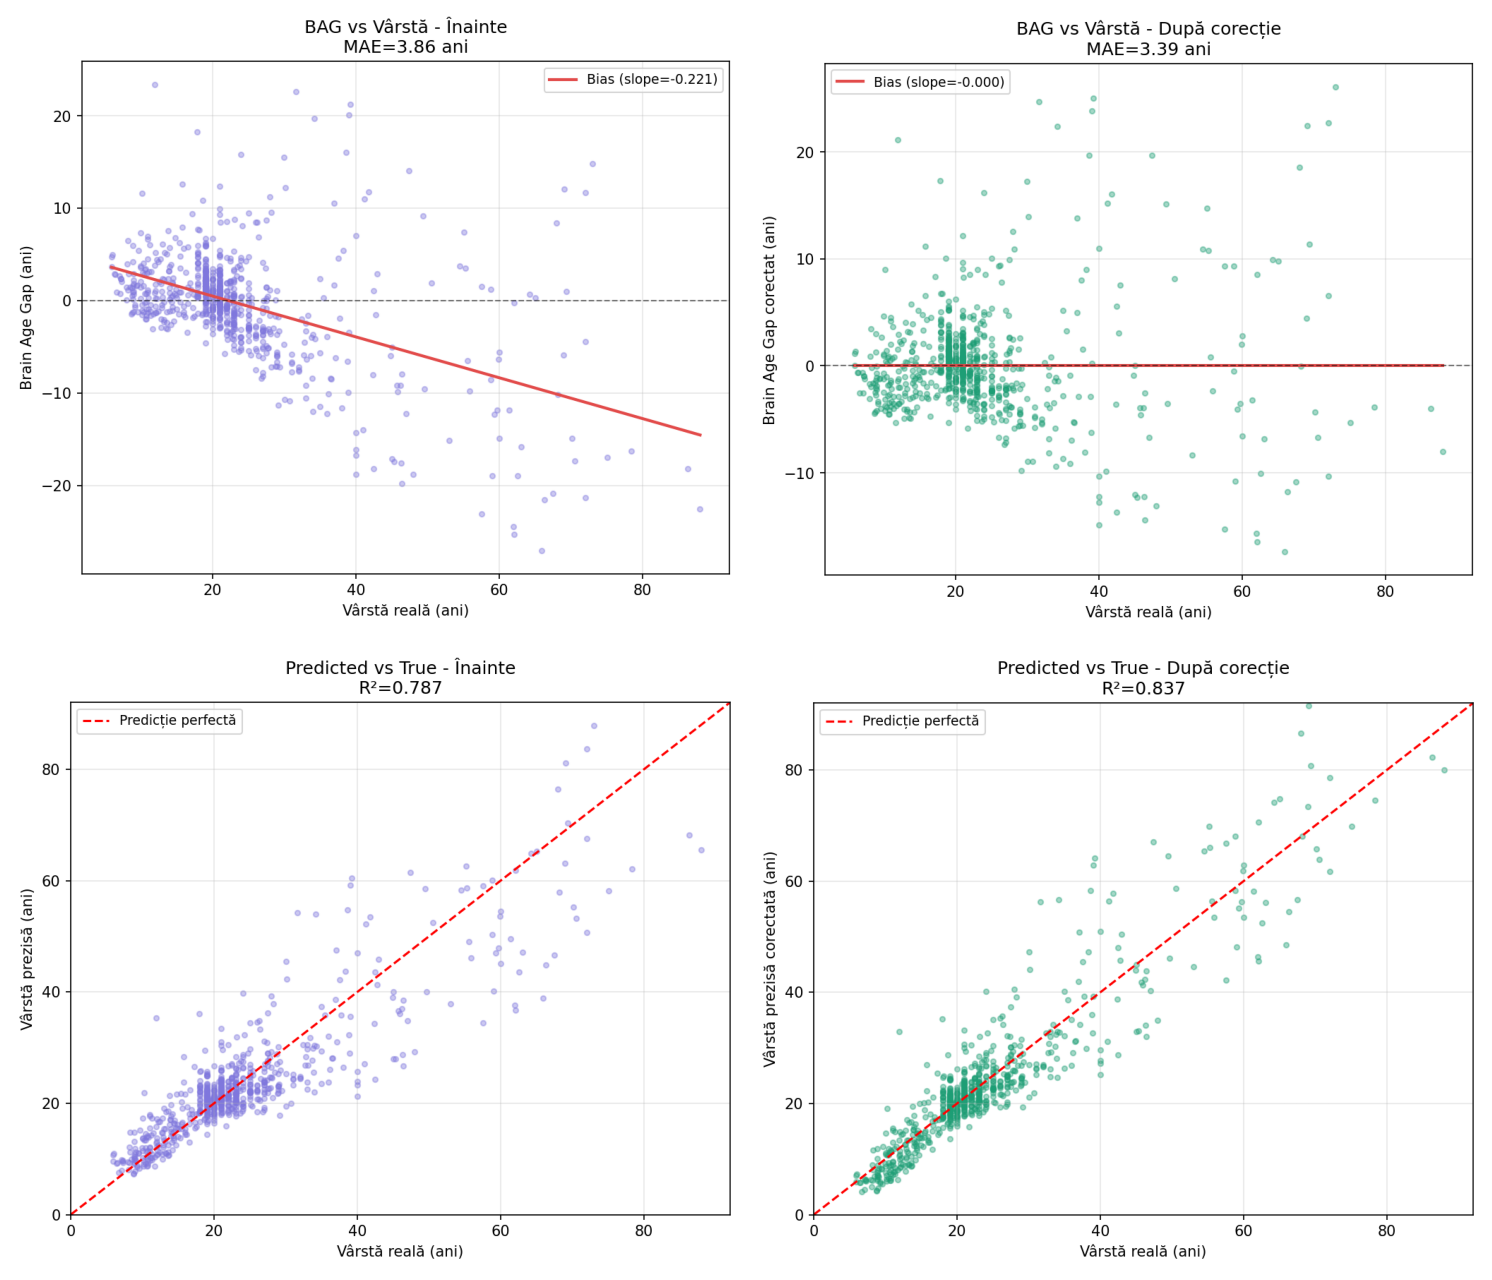

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

imagini = [
    '/kaggle/input/datasets/craciunramona/rezultate/bag_inainte.png',
    '/kaggle/input/datasets/craciunramona/rezultate/bag_dupa.png',
    '/kaggle/input/datasets/craciunramona/rezultate/pred_inainte.png',
    '/kaggle/input/datasets/craciunramona/rezultate/pred_dupa.png'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 13))

for ax, cale_img in zip(axes.ravel(), imagini):
    img = mpimg.imread(cale_img)
    ax.imshow(img)
    ax.axis('off') 

plt.tight_layout(pad=1.0)
plt.show()

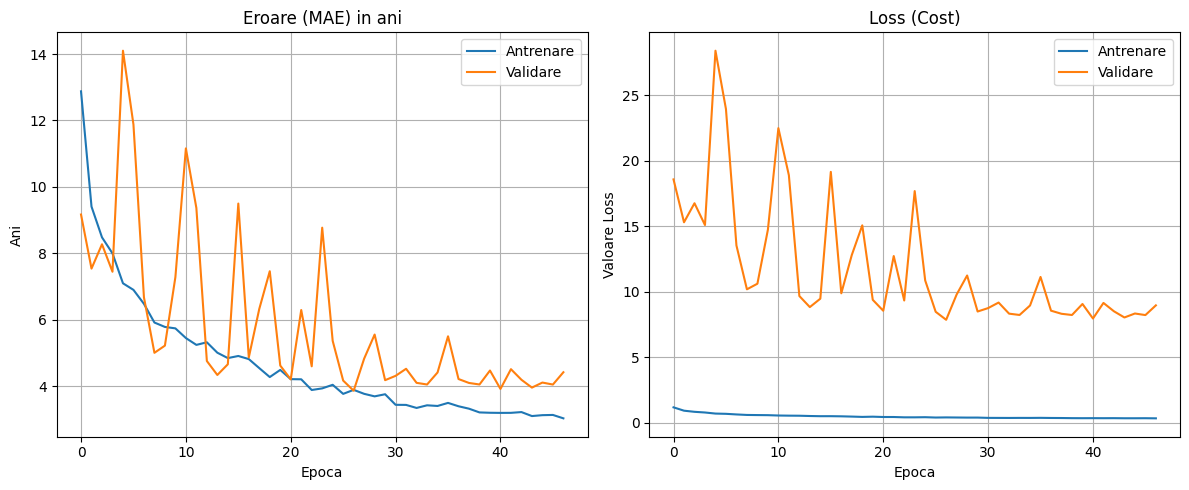

Cea mai mică eroare pe validare: 3.8607 ani


In [18]:
import pickle
import matplotlib.pyplot as plt

# 1. Incarcare date
with open('/kaggle/working/history_final.pkl', 'rb') as f:
    history = pickle.load(f)

# 2. Creare spatiu pentru grafice
plt.figure(figsize=(12, 5))

# GRAFIC 1: MAE (Eroarea in ani)
plt.subplot(1, 2, 1)
plt.plot(history['mae'], label='Antrenare')
plt.plot(history['val_mae'], label='Validare')
plt.title('Eroare (MAE) in ani')
plt.xlabel('Epoca')
plt.ylabel('Ani')
plt.legend()
plt.grid(True)

# GRAFIC 2: LOSS
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Antrenare')
plt.plot(history['val_loss'], label='Validare')
plt.title('Loss (Cost)')
plt.xlabel('Epoca')
plt.ylabel('Valoare Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Printare rapida a celui mai bun rezultat
print(f"Cea mai mica eroare pe validare: {min(history['val_mae']):.4f} ani")

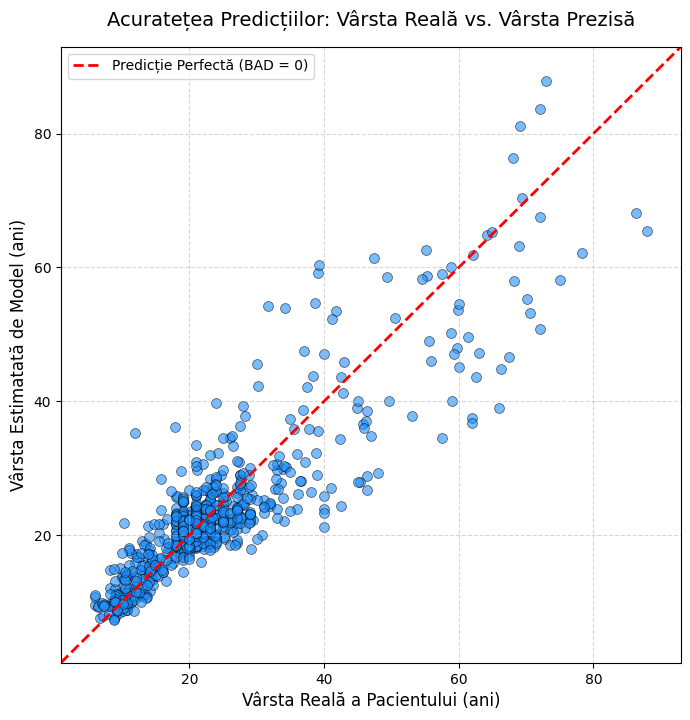

In [16]:
import seaborn as sns


plt.figure(figsize=(8, 8))

sns.scatterplot(x=y_true_final, y=y_pred_final, alpha=0.6, color='dodgerblue', edgecolor='k', s=50)

min_val = min(min(y_true_final), min(y_pred_final)) - 5
max_val = max(max(y_true_final), max(y_pred_final)) + 5

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predictie Perfecta (BAD = 0)')

plt.title('Acuratetea Predictiilor: Varsta Reala vs. Varsta Prezisa', fontsize=14, pad=15)
plt.xlabel('Varsta Reala a Pacientului (ani)', fontsize=12)
plt.ylabel('Varsta Estimatata de Model (ani)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])

plt.show()